This notebook code allow us to detect and classify palm trees.

Dataset de test

In [26]:
import os
import cv2
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm

yolo_env_classifier = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\classification_per_type\environment_classification_dataset\yolov11m_cls\fixed_ot\environment_classification_model_fixed_ot\weights\best.pt"
yolo_palm_classifier = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\classification_per_type\palm_type_classification_dataset\yolov11m_cls\palm_type_classification_model_45px\weights\best.pt"
test_dir = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\fixed_normalization\Test\images"
output_csv = "clasificacion_resultados.csv"

# Cargar modelos
detection_dir = r"C:\Users\hugoh\OneDrive\Documentos\ArcGIS\Projects\TFG_palmeras\runs\detect\fixed_normalization\bbox_45\train_yolov11m\weights\best.pt"
detector = YOLO(detection_dir)
classifier_pal = YOLO(yolo_palm_classifier)
classifier_env = YOLO(yolo_env_classifier)

# Inicializar resultados
rows = []

# Procesar imágenes
for filename in tqdm(os.listdir(test_dir), desc="Procesando imágenes"):
    if not filename.lower().endswith(('.png')):
        continue

    image_path = os.path.join(test_dir, filename)
    image = cv2.imread(image_path)
    if image is None:
        print(f"No se pudo leer: {filename}")
        continue

    img_h, img_w = image.shape[:2]

    # Detección de palmeras
    results = detector.predict(
        source=image,
        conf=0.184,
        device=0,
        imgsz=960)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        print(x1, y1, x2, y2)
        conf = float(box.conf[0])

        # Clasificación tipo palmera
        bbox_crop = image[y1:y2, x1:x2]
        if bbox_crop.size == 0:
            continue
        pal_result = classifier_pal(bbox_crop)[0]
        pal_class = int(pal_result.probs.top1)
        pal_conf = float(pal_result.probs.top1conf)

        #  Clasificación tipo ambiente
        xc = int((x1 + x2) / 2)
        yc = int((y1 + y2) / 2)
        roi_size = 256
        env_x1 = max(0, xc - roi_size // 2)
        env_y1 = max(0, yc - roi_size // 2)
        env_x2 = min(img_w, xc + roi_size // 2)
        env_y2 = min(img_h, yc + roi_size // 2)
        env_crop = image[env_y1:env_y2, env_x1:env_x2]
        if env_crop.size == 0:
            continue
        env_result = classifier_env(env_crop)[0]
        env_class = int(env_result.probs.top1)
        env_conf = float(env_result.probs.top1conf)

        # Guardar fila
        rows.append({
            "image": filename,
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "det_confidence": conf,
            "palm_class": pal_class,
            "palm_confidence": pal_conf,
            "environment_class": env_class,
            "environment_confidence": env_conf
        })

# Guardar CSV
df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)
print(f"Clasificación finalizada. Resultados guardados en: {output_csv}")

Procesando imágenes:   0%|          | 0/23 [00:00<?, ?it/s]


0: 704x960 1 item, 53.0ms
Speed: 4.2ms preprocess, 53.0ms inference, 1.9ms postprocess per image at shape (1, 3, 704, 960)
374 374 421 422

0: 64x64 pc 0.58, bdc 0.14, pme 0.13, hme 0.07, da 0.07, 4.4ms
Speed: 1.0ms preprocess, 4.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.44, vi 0.39, ru 0.15, ot 0.01, uj 0.01, 4.4ms
Speed: 1.9ms preprocess, 4.4ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)


Procesando imágenes:   4%|▍         | 1/23 [00:00<00:21,  1.04it/s]


0: 704x960 14 items, 26.6ms
Speed: 4.0ms preprocess, 26.6ms inference, 1.7ms postprocess per image at shape (1, 3, 704, 960)
221 446 265 491

0: 64x64 pc 0.30, tdi 0.24, pme 0.21, da 0.10, bdc 0.08, 4.7ms
Speed: 1.4ms preprocess, 4.7ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.92, ru 0.07, rd 0.01, vi 0.00, ot 0.00, 4.3ms
Speed: 1.9ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
350 402 395 447

0: 64x64 tdi 0.33, pc 0.19, pme 0.17, hme 0.15, da 0.10, 5.0ms
Speed: 1.1ms preprocess, 5.0ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.91, ru 0.07, ot 0.01, rd 0.01, vi 0.01, 4.3ms
Speed: 1.7ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
111 539 157 586

0: 64x64 pme 0.35, pc 0.20, tdi 0.16, bdc 0.15, da 0.08, 4.5ms
Speed: 1.1ms preprocess, 4.5ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.88, ru 0.10, ot 0

Procesando imágenes:   9%|▊         | 2/23 [00:01<00:12,  1.72it/s]

...


0: 704x960 16 items, 26.8ms
Speed: 3.8ms preprocess, 26.8ms inference, 4.7ms postprocess per image at shape (1, 3, 704, 960)
516 683 556 722

0: 64x64 pc 0.55, pme 0.13, hme 0.12, bdc 0.10, tdi 0.08, 5.6ms
Speed: 1.9ms preprocess, 5.6ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.81, ru 0.19, rd 0.00, ot 0.00, vi 0.00, 4.6ms
Speed: 3.8ms preprocess, 4.6ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
801 416 841 454

0: 64x64 pc 0.67, tdi 0.19, bdc 0.05, pme 0.05, hme 0.04, 10.5ms
Speed: 1.5ms preprocess, 10.5ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.66, ru 0.32, ot 0.01, vi 0.00, rd 0.00, 4.3ms
Speed: 1.6ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
447 608 489 649

0: 64x64 pc 0.70, tdi 0.15, hme 0.06, pme 0.05, bdc 0.02, 7.9ms
Speed: 0.9ms preprocess, 7.9ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.64, ru 0.36,

Procesando imágenes:  96%|█████████▌| 22/23 [00:14<00:00,  1.30it/s]


0: 704x960 3 items, 26.1ms
Speed: 3.8ms preprocess, 26.1ms inference, 1.8ms postprocess per image at shape (1, 3, 704, 960)
770 549 816 594

0: 64x64 tdi 0.40, pme 0.25, pc 0.15, hme 0.14, bdc 0.04, 3.4ms
Speed: 0.8ms preprocess, 3.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.41, ru 0.34, vi 0.14, rd 0.05, ud 0.02, 3.7ms
Speed: 1.5ms preprocess, 3.7ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
572 23 619 70

0: 64x64 pc 0.68, da 0.16, hme 0.07, pme 0.05, bdc 0.03, 3.6ms
Speed: 0.9ms preprocess, 3.6ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 na 0.64, ot 0.15, ru 0.12, vi 0.05, uj 0.02, 4.7ms
Speed: 1.7ms preprocess, 4.7ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
547 464 592 510

0: 64x64 pme 0.50, pc 0.35, tdi 0.14, hme 0.01, bdc 0.00, 4.0ms
Speed: 0.8ms preprocess, 4.0ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ru 0.46, na 0.43, rd 0.

Procesando imágenes: 100%|██████████| 23/23 [00:14<00:00,  1.55it/s]

Clasificación finalizada. Resultados guardados en: clasificacion_resultados.csv


Comprobamos Verdaderos o Falsos Positivos

In [27]:
import os
import json
import pandas as pd

json_dir = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\fixed_normalization\Test\json_annotations"
output_csv = "ground_truth.csv"

rows = []

for file in os.listdir(json_dir):
    if not file.endswith(".json"):
        continue

    with open(os.path.join(json_dir, file), "r", encoding="utf-8") as f:
        data = json.load(f)

    image_name = data["image"]
    palm_id = data.get("id", "unknown")

    for palm in data.get("palms", []):
        bbox = palm["bbox_pixel"]
        xc = bbox["x_center"]
        yc = bbox["y_center"]
        w = bbox["width"]
        h = bbox["height"]
        x1 = int(xc - w / 2)
        y1 = int(yc - h / 2)
        x2 = int(xc + w / 2)
        y2 = int(yc + h / 2)

        environment = palm["attributes"].get("Tip_amb")
        palm_type = palm["attributes"].get("Hibrid")

        # Solo incluimos palmas con clase conocida
        if environment == "?" or palm_type == "?":
            continue

        # Mapea clases a IDs (asegúrate que coincide con lo que usaste para entrenar)
        environment_class = {"na": 0, "ot": 1, "rd" : 2, "ru": 3, "ud": 4, "uj": 5, "vi": 6}[environment.lower()]
        palm_class = {"bdc": 0, "da": 1, "hme": 2, "pc": 3, "pme": 4, "tdi": 5}[palm_type.lower()]
        rows.append({
            "image": image_name,
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "palm_class": palm_class,
            "environment_class": environment_class
        })

df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)
print(f"ground_truth.csv guardado en: {output_csv}")

ground_truth.csv guardado en: ground_truth.csv


In [28]:
import pandas as pd

gt = pd.read_csv("ground_truth_2.csv")
pred = pd.read_csv("clasificacion_resultados_2.csv")

print("Ground truth:", len(gt))
print("Clasificaciones realizadas:", len(pred))

print("\nImágenes en común:", len(set(gt["image"]) & set(pred["image"])))

Ground truth: 1232
Clasificaciones realizadas: 76

Imágenes en común: 14


Ahora, comparamos resultados de las predicciones con las detecciones y etiquetas reales

Resultados:
True Positives (TP): 415
False Positives (FP): 371
False Negatives (FN): 817
Precisión detección: 0.53
Recall detección: 0.34
Accuracy clasificación ambiente: 229/415 = 0.55
Accuracy clasificación tipo palmera: 298/415 = 0.72


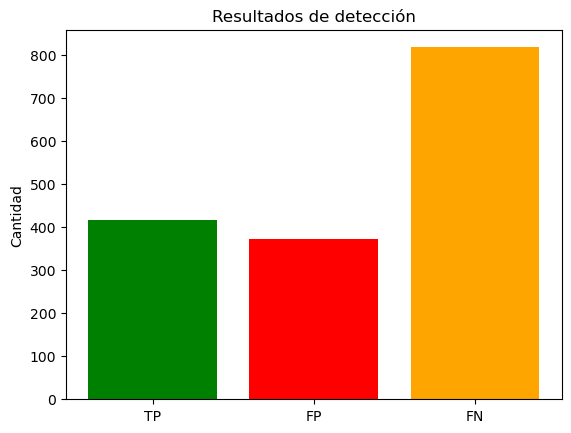

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# === Función para calcular IoU ===
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interWidth = max(0, xB - xA + 1)
    interHeight = max(0, yB - yA + 1)
    interArea = interWidth * interHeight
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Cargar CSVs
gt_df = pd.read_csv("ground_truth.csv")
pred_df = pd.read_csv("clasificacion_resultados.csv")

tp, fp, fn = 0, 0, 0
correct_env_cls, correct_palm_cls = 0, 0
total_env_cls, total_palm_cls = 0, 0

matched_gt = set()

# === Comparación detección y clasificación ===
for _, pred in pred_df.iterrows():
    found_match = False
    pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
    image = pred["image"]

    gt_image_df = gt_df[gt_df["image"] == image]

    for gt_idx, gt in gt_image_df.iterrows():
        gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
        iou = calculate_iou(pred_box, gt_box)

        if iou >= 0.4 and gt_idx not in matched_gt:
            found_match = True
            matched_gt.add(gt_idx)
            tp += 1

            total_env_cls += 1
            total_palm_cls += 1

            if pred["environment_class"] == gt["environment_class"]:
                correct_env_cls += 1
            if pred["palm_class"] == gt["palm_class"]:
                correct_palm_cls += 1
            break

    if not found_match:
        fp += 1

fn = len(gt_df) - len(matched_gt)

# Mostrar métricas
print(f"Resultados:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precisión detección: {tp / (tp + fp):.2f}")
print(f"Recall detección: {tp / (tp + fn):.2f}")
print(f"Accuracy clasificación ambiente: {correct_env_cls}/{total_env_cls} = {correct_env_cls / total_env_cls:.2f}")
print(f"Accuracy clasificación tipo palmera: {correct_palm_cls}/{total_palm_cls} = {correct_palm_cls / total_palm_cls:.2f}")

# Gráfica de barras
plt.bar(["TP", "FP", "FN"], [tp, fp, fn], color=["green", "red", "orange"])
plt.title("Resultados de detección")
plt.ylabel("Cantidad")
plt.show()

Resultados (sin filtrar duplicados por ground truth):
True Positives (TP): 491
False Positives (FP): 295
False Negatives (FN): 829
Precisión detección: 0.62
Recall detección: 0.37
Accuracy ambiente: 276/491 = 0.56
Accuracy tipo palmera: 356/491 = 0.73


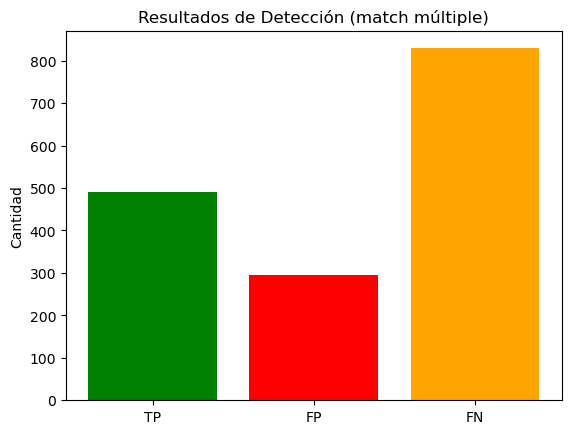

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Cargar CSVs
gt_df = pd.read_csv("ground_truth.csv")
pred_df = pd.read_csv("clasificacion_resultados.csv")

tp, fp, fn = 0, 0, 0
correct_env_cls, correct_palm_cls = 0, 0
total_env_cls, total_palm_cls = 0, 0

# === Comparación sin restringir matches
for _, pred in pred_df.iterrows():
    pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
    image = pred["image"]
    gt_image_df = gt_df[gt_df["image"] == image]

    matched = False

    for _, gt in gt_image_df.iterrows():
        gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
        iou = calculate_iou(pred_box, gt_box)

        if iou >= 0.5:
            matched = True
            tp += 1
            total_env_cls += 1
            total_palm_cls += 1
            if pred["environment_class"] == gt["environment_class"]:
                correct_env_cls += 1
            if pred["palm_class"] == gt["palm_class"]:
                correct_palm_cls += 1
            break  # Si quieres permitir múltiples matches por GT, quita este `break`

    if not matched:
        fp += 1

# Cada GT que no tiene ninguna detección encima, cuenta como FN
# Para esto necesitamos ver qué GTs no tienen ninguna detección asociada
# Repetimos proceso inverso para contarlos

detected_gt_indices = set()
for _, gt in gt_df.iterrows():
    gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
    image = gt["image"]
    pred_image_df = pred_df[pred_df["image"] == image]

    matched = False
    for _, pred in pred_image_df.iterrows():
        pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
        if calculate_iou(gt_box, pred_box) >= 0.5:
            matched = True
            break

    if not matched:
        fn += 1

# Mostrar métricas
print("Resultados (sin filtrar duplicados por ground truth):")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precisión detección: {tp / (tp + fp):.2f}")
print(f"Recall detección: {tp / (tp + fn):.2f}")
print(f"Accuracy ambiente: {correct_env_cls}/{total_env_cls} = {correct_env_cls / total_env_cls:.2f}")
print(f"Accuracy tipo palmera: {correct_palm_cls}/{total_palm_cls} = {correct_palm_cls / total_palm_cls:.2f}")

# Visualización
plt.bar(["TP", "FP", "FN"], [tp, fp, fn], color=["green", "red", "orange"])
plt.title("Resultados de Detección (match múltiple)")
plt.ylabel("Cantidad")
plt.show()


Ahora, usaremos el mejor modelo de clasificación (aparte de los propios de YOLO). Para ambos casos de clasificación, usaremos un fine-tunning de ResNet50. 

In [22]:
import os
import cv2
import torch
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
from torchvision import models, transforms
from torch.nn import functional as F
from ultralytics import YOLO

# Rutas
detection_model_path = r"C:\Users\hugoh\OneDrive\Documentos\ArcGIS\Projects\TFG_palmeras\runs\detect\fixed_normalization\bbox_45\train_yolov11m\weights\best.pt"
resnet_palm_path = r"cls_models\cls_type\resnet50_best.pth"
resnet_env_path = r"cls_models\cls_env\resnet50_best.pth"
test_dir = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\fixed_normalization\Test\images"
output_csv = r".\detect_and_classify_csv\yolo_and_resnet\clasificacion_resultados_resnet.csv"

# Cargar modelo YOLO de detección
detector = YOLO(detection_model_path)

# Transforms para ResNet
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Cargar modelo ResNet para tipo de palmera
resnet_palm = models.resnet50(weights=None)
resnet_palm.fc = nn.Sequential(
    nn.Dropout(p=0.6),
    nn.Linear(resnet_palm.fc.in_features, 6)
)
resnet_palm.load_state_dict(torch.load(resnet_palm_path, map_location='cpu'))
resnet_palm.eval()

# Cargar modelo ResNet para ambiente
resnet_env = models.resnet50(weights=None)
resnet_env.fc = nn.Sequential(
    nn.Dropout(p=0.6),
    nn.Linear(resnet_env.fc.in_features, 7)
)
resnet_env.load_state_dict(torch.load(resnet_env_path, map_location='cpu'))
resnet_env.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_palm.to(device)
resnet_env.to(device)

rows = []

for filename in tqdm(os.listdir(test_dir), desc="Procesando imágenes"):
    if not filename.lower().endswith('.png'):
        continue

    image_path = os.path.join(test_dir, filename)
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error leyendo {filename}")
        continue

    img_h, img_w = image.shape[:2]

    # Detección con YOLO
    results = detector.predict(source=image, conf=0.184, device=0, imgsz=960)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        # -------- Clasificación tipo de palmera (crop de bbox) --------
        palm_crop = image[y1:y2, x1:x2]
        if palm_crop.size == 0:
            continue

        palm_tensor = transform(palm_crop).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = resnet_palm(palm_tensor)
            probs = F.softmax(logits, dim=1)
            palm_class = int(torch.argmax(probs, dim=1).item())
            palm_conf = float(torch.max(probs).item())

        # -------- Clasificación tipo de ambiente (ROI centrado) --------
        xc, yc = (x1 + x2) // 2, (y1 + y2) // 2
        roi_size = 256
        env_x1 = max(0, xc - roi_size // 2)
        env_y1 = max(0, yc - roi_size // 2)
        env_x2 = min(img_w, xc + roi_size // 2)
        env_y2 = min(img_h, yc + roi_size // 2)
        env_crop = image[env_y1:env_y2, env_x1:env_x2]
        if env_crop.size == 0:
            continue

        env_tensor = transform(env_crop).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = resnet_env(env_tensor)
            probs = F.softmax(logits, dim=1)
            env_class = int(torch.argmax(probs, dim=1).item())
            env_conf = float(torch.max(probs).item())

        # Guardar resultados
        rows.append({
            "image": filename,
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "det_confidence": conf,
            "palm_class": palm_class,
            "palm_confidence": palm_conf,
            "environment_class": env_class,
            "environment_confidence": env_conf
        })

# Guardar CSV
df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)
print(f"Guardado: {output_csv}")

Procesando imágenes:   0%|          | 0/23 [00:00<?, ?it/s]


0: 704x960 1 item, 26.1ms
Speed: 4.5ms preprocess, 26.1ms inference, 1.8ms postprocess per image at shape (1, 3, 704, 960)


Procesando imágenes:   4%|▍         | 1/23 [00:00<00:06,  3.34it/s]


0: 704x960 14 items, 25.8ms
Speed: 4.1ms preprocess, 25.8ms inference, 1.7ms postprocess per image at shape (1, 3, 704, 960)


Procesando imágenes:   9%|▊         | 2/23 [00:00<00:06,  3.47it/s]

...


0: 704x960 16 items, 20.5ms
Speed: 4.1ms preprocess, 20.5ms inference, 1.6ms postprocess per image at shape (1, 3, 704, 960)


Procesando imágenes:  96%|█████████▌| 22/23 [00:13<00:00,  1.26it/s]


0: 704x960 3 items, 21.7ms
Speed: 4.8ms preprocess, 21.7ms inference, 2.9ms postprocess per image at shape (1, 3, 704, 960)


Procesando imágenes: 100%|██████████| 23/23 [00:13<00:00,  1.69it/s]

Guardado: .\detect_and_classify_csv\yolo_and_resnet\clasificacion_resultados_resnet.csv


In [30]:
import pandas as pd

csv_dir = r".\detect_and_classify_csv\yolo_and_resnet"

gt = pd.read_csv("ground_truth.csv")
pred = pd.read_csv(os.path.join(csv_dir, "clasificacion_resultados_resnet.csv"))

print("Ground truth:", len(gt))
print("Clasificaciones realizadas:", len(pred))

print("\nImágenes en común:", len(set(gt["image"]) & set(pred["image"])))

Ground truth: 1232
Clasificaciones realizadas: 786

Imágenes en común: 22


Resultados:
True Positives (TP): 415
False Positives (FP): 371
False Negatives (FN): 817
Precisión detección: 0.53
Recall detección: 0.34
Accuracy clasificación ambiente: 225/415 = 0.54
Accuracy clasificación tipo palmera: 263/415 = 0.63


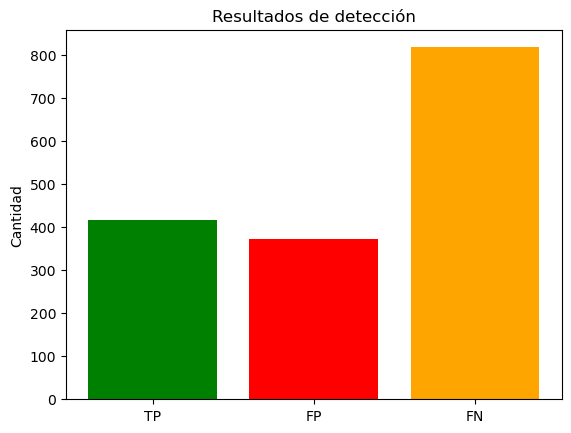

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# === Función para calcular IoU ===
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interWidth = max(0, xB - xA + 1)
    interHeight = max(0, yB - yA + 1)
    interArea = interWidth * interHeight
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Cargar CSVs
gt_df = pd.read_csv("ground_truth.csv")
pred_df = pd.read_csv(r"detect_and_classify_csv\yolo_and_resnet\clasificacion_resultados_resnet.csv")

tp, fp, fn = 0, 0, 0
correct_env_cls, correct_palm_cls = 0, 0
total_env_cls, total_palm_cls = 0, 0

matched_gt = set()

# === Comparación detección y clasificación ===
for _, pred in pred_df.iterrows():
    found_match = False
    pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
    image = pred["image"]

    gt_image_df = gt_df[gt_df["image"] == image]

    for gt_idx, gt in gt_image_df.iterrows():
        gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
        iou = calculate_iou(pred_box, gt_box)

        if iou >= 0.4 and gt_idx not in matched_gt:
            found_match = True
            matched_gt.add(gt_idx)
            tp += 1

            total_env_cls += 1
            total_palm_cls += 1

            if pred["environment_class"] == gt["environment_class"]:
                correct_env_cls += 1
            if pred["palm_class"] == gt["palm_class"]:
                correct_palm_cls += 1
            break

    if not found_match:
        fp += 1

fn = len(gt_df) - len(matched_gt)

# Mostrar métricas
print(f"Resultados:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precisión detección: {tp / (tp + fp):.2f}")
print(f"Recall detección: {tp / (tp + fn):.2f}")
print(f"Accuracy clasificación ambiente: {correct_env_cls}/{total_env_cls} = {correct_env_cls / total_env_cls:.2f}")
print(f"Accuracy clasificación tipo palmera: {correct_palm_cls}/{total_palm_cls} = {correct_palm_cls / total_palm_cls:.2f}")

# Gráfica de barras
plt.bar(["TP", "FP", "FN"], [tp, fp, fn], color=["green", "red", "orange"])
plt.title("Resultados de detección")
plt.ylabel("Cantidad")
plt.show()

Resultados (sin filtrar duplicados por ground truth):
True Positives (TP): 491
False Positives (FP): 295
False Negatives (FN): 829
Precisión detección: 0.62
Recall detección: 0.37
Accuracy ambiente: 266/491 = 0.54
Accuracy tipo palmera: 320/491 = 0.65


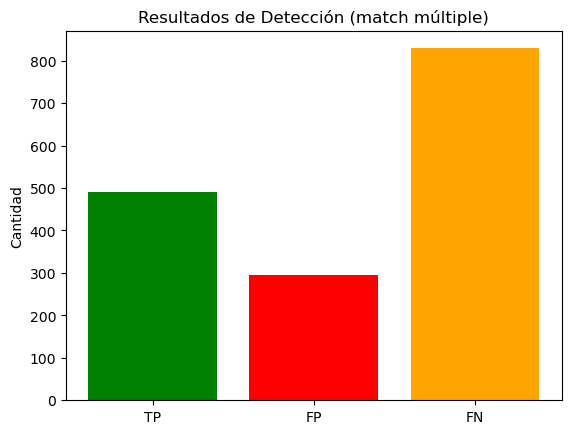

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Cargar CSVs
gt_df = pd.read_csv("ground_truth.csv")
pred_df = pd.read_csv(r"detect_and_classify_csv\yolo_and_resnet\clasificacion_resultados_resnet.csv")

tp, fp, fn = 0, 0, 0
correct_env_cls, correct_palm_cls = 0, 0
total_env_cls, total_palm_cls = 0, 0

# === Comparación sin restringir matches
for _, pred in pred_df.iterrows():
    pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
    image = pred["image"]
    gt_image_df = gt_df[gt_df["image"] == image]

    matched = False

    for _, gt in gt_image_df.iterrows():
        gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
        iou = calculate_iou(pred_box, gt_box)

        if iou >= 0.5:
            matched = True
            tp += 1
            total_env_cls += 1
            total_palm_cls += 1
            if pred["environment_class"] == gt["environment_class"]:
                correct_env_cls += 1
            if pred["palm_class"] == gt["palm_class"]:
                correct_palm_cls += 1
            break  # Si quieres permitir múltiples matches por GT, quita este `break`

    if not matched:
        fp += 1

# Cada GT que no tiene ninguna detección encima, cuenta como FN
# Para esto necesitamos ver qué GTs no tienen ninguna detección asociada
# Repetimos proceso inverso para contarlos

detected_gt_indices = set()
for _, gt in gt_df.iterrows():
    gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
    image = gt["image"]
    pred_image_df = pred_df[pred_df["image"] == image]

    matched = False
    for _, pred in pred_image_df.iterrows():
        pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
        if calculate_iou(gt_box, pred_box) >= 0.5:
            matched = True
            break

    if not matched:
        fn += 1

# Mostrar métricas
print("Resultados (sin filtrar duplicados por ground truth):")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precisión detección: {tp / (tp + fp):.2f}")
print(f"Recall detección: {tp / (tp + fn):.2f}")
print(f"Accuracy ambiente: {correct_env_cls}/{total_env_cls} = {correct_env_cls / total_env_cls:.2f}")
print(f"Accuracy tipo palmera: {correct_palm_cls}/{total_palm_cls} = {correct_palm_cls / total_palm_cls:.2f}")

# Visualización
plt.bar(["TP", "FP", "FN"], [tp, fp, fn], color=["green", "red", "orange"])
plt.title("Resultados de Detección (match múltiple)")
plt.ylabel("Cantidad")
plt.show()


In [17]:
import torch

def get_num_classes_from_model(path_to_model):
    state_dict = torch.load(path_to_model, map_location='cpu')

    # Buscar el último Linear layer (fc.1.weight o fc.weight)
    for key in state_dict.keys():
        if 'fc.1.weight' in key:
            return state_dict[key].shape[0]  # Número de clases
        if 'fc.weight' in key:
            return state_dict[key].shape[0]

    return "No se encontró capa de salida en el modelo."

# Ejemplo de uso:
resnet_palm_path = r"cls_models\cls_type\resnet50_best.pth"
resnet_env_path = r"cls_models\cls_env\resnet50_best.pth"

print("Palm model num classes:", get_num_classes_from_model(resnet_palm_path))
print("Environment model num classes:", get_num_classes_from_model(resnet_env_path))


Palm model num classes: 6
Environment model num classes: 7
